In [1]:
import pdfplumber

def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text()
    return text

pdf_path = ("Liu et al_2022_TBEM.pdf")
text = extract_text_from_pdf(pdf_path)

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    # 去除标点符号
    text = re.sub(r'[^\w\s]', '', text)
    # 转换为小写
    text = text.lower()
    # 分词
    tokens = word_tokenize(text)
    # 去除停用词
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
processed_text = preprocess_text(text)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jiabo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jiabo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jiabo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jiabo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jiabo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-m3')
sentences = processed_text.split(' ')  # 假设按句子分割
sentence_embeddings = model.encode(sentences)

In [34]:
from sklearn.cluster import KMeans

num_clusters = 10  # 假设分为5个簇
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(sentence_embeddings)
clusters = kmeans.labels_

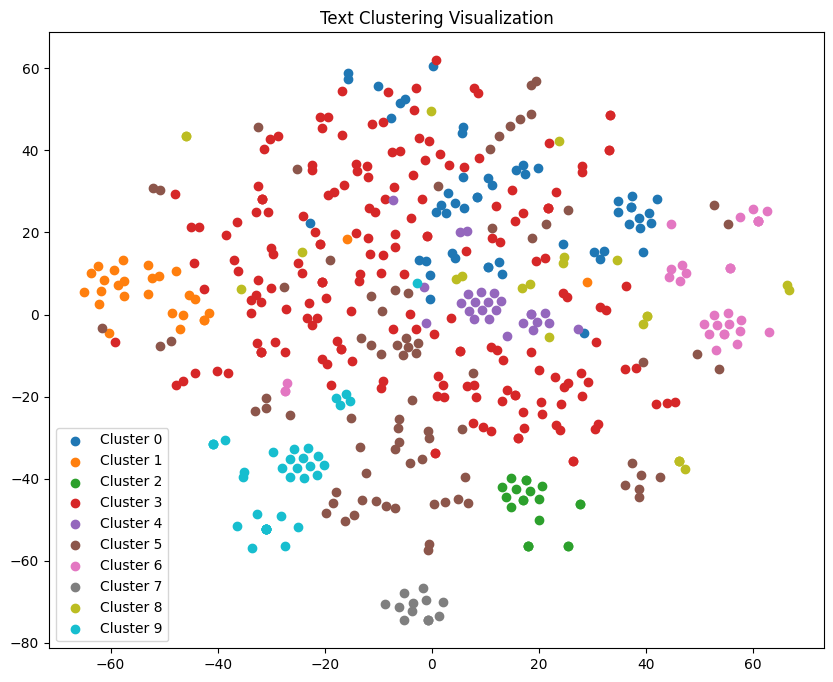

In [35]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 使用t-SNE降维
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(sentence_embeddings)

# 可视化
plt.figure(figsize=(10, 8))
for i in range(num_clusters):
    plt.scatter(embeddings_2d[clusters == i, 0], embeddings_2d[clusters == i, 1], label=f'Cluster {i}')
plt.legend()
plt.title('Text Clustering Visualization')
plt.show()